# Naive Bayes Algorithm

## 1. Introduction to Naive Bayes

The Naive Bayes algorithm is a classification technique based on Bayes' Theorem with an assumption of independence among predictors. In simple terms, a Naive Bayes classifier assumes that the presence of a particular feature in a class is unrelated to the presence of any other feature.

For example, a fruit may be considered to be an apple if it is red, round, and about 3 inches in diameter. Even if these features depend on each other or upon the existence of the other features, all of these properties independently contribute to the probability that this fruit is an apple and that is why it is known as 'Naive'.

## 2. Types of Naive Bayes Classifiers

There are several types of Naive Bayes classifiers, and the choice depends on the nature of the features.

*   **Gaussian Naive Bayes:** Used for features that are continuous and follow a Gaussian (normal) distribution. This is what we used in our first example with the Iris dataset.
*   **Multinomial Naive Bayes:** Suitable for discrete features. It is widely used for text classification problems where the features are word counts or frequencies (e.g., TF-IDF).
*   **Bernoulli Naive Bayes:** Used for binary/boolean features (features that take only two values, like 'yes' or 'no', 'true' or 'false').

### 2.1. Gaussian Naive Bayes

Gaussian Naive Bayes is used for classification tasks where the features are continuous and follow a Gaussian (normal) distribution. 

We will use the Iris dataset to demonstrate Gaussian Naive Bayes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import ListedColormap

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

#### Data Splitting

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Training the Gaussian Naive Bayes Model

In [3]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


#### Predictions and Evaluation

In [4]:
y_pred = gnb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9777777777777777

Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



#### Visualizing Decision Boundaries

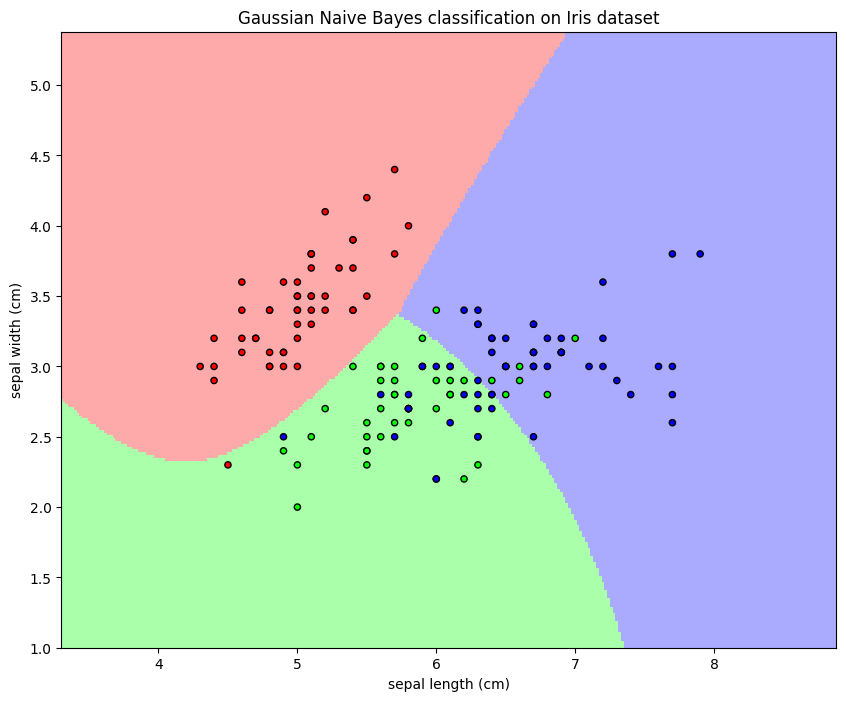

In [5]:
# For visualization, we'll only use two features
X_vis = iris.data[:, :2]
y_vis = iris.target

gnb_vis = GaussianNB()
gnb_vis.fit(X_vis, y_vis)

h = .02  # step size in the mesh
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = gnb_vis.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("Gaussian Naive Bayes classification on Iris dataset")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

### 2.2. Multinomial Naive Bayes

Multinomial Naive Bayes is suitable for classification with discrete features (e.g., word counts for text classification). It is commonly used in natural language processing (NLP).

We will use the 20 Newsgroups dataset for this example.

In [6]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Load the dataset
data = fetch_20newsgroups()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

# Create a pipeline that vectorizes the data and then applies Multinomial Naive Bayes
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Train the model
model.fit(X_train, y_train)

,steps,"[('tfidfvectorizer', ...), ('multinomialnb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


#### Predictions and Evaluation

In [7]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.8391752577319588

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.93      0.76      0.83       135
           comp.graphics       0.84      0.78      0.81       166
 comp.os.ms-windows.misc       0.87      0.77      0.82       170
comp.sys.ibm.pc.hardware       0.69      0.83      0.76       182
   comp.sys.mac.hardware       0.94      0.76      0.84       183
          comp.windows.x       0.89      0.89      0.89       169
            misc.forsale       0.90      0.72      0.80       172
               rec.autos       0.89      0.91      0.90       191
         rec.motorcycles       0.95      0.91      0.93       198
      rec.sport.baseball       0.93      0.93      0.93       168
        rec.sport.hockey       0.90      0.99      0.94       163
               sci.crypt       0.84      0.96      0.89       195
         sci.electronics       0.89      0.76      0.82       177
                 sci.

### 2.3. Bernoulli Naive Bayes

Bernoulli Naive Bayes is used for binary/boolean features. It is useful when the features are binary (i.e., they take only two values, such as 0 and 1, or True and False).

Here's a simple example with a synthetic dataset.

In [8]:
from sklearn.naive_bayes import BernoulliNB
import numpy as np

# Create a synthetic dataset with binary features
# Features: [feature1, feature2, feature3]
X = np.array([[0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 0, 0]])
y = np.array([0, 1, 0, 1, 0, 1])

# Train the Bernoulli Naive Bayes model
bnb = BernoulliNB()
bnb.fit(X, y)

# Make predictions
test_data = np.array([[1, 1, 1]])
prediction = bnb.predict(test_data)
print(f"Prediction for {test_data}: {prediction}")

print("\nModel Accuracy:", bnb.score(X,y))

Prediction for [[1 1 1]]: [0]

Model Accuracy: 1.0


## 3. Pros and Cons of Naive Bayes

### Pros
* **Easy and fast to implement:** Naive Bayes is a simple and efficient algorithm.
* **Works well with high-dimensional data:** It performs well in cases of high-dimensional data, such as text classification.
* **Good performance:** Despite the naive assumption of feature independence, it often performs surprisingly well.
* **Requires less training data:** It can make predictions with a small amount of training data.

### Cons
* **Strong feature independence assumption:** The main limitation of Naive Bayes is the assumption of independent predictors. In real life, it is almost impossible that we get a set of predictors which are completely independent.
* **Zero Frequency Problem:** If a categorical variable has a category in the test data set, which was not observed in the training data set, then the model will assign a 0 (zero) probability and will be unable to make a prediction. This is often handled by smoothing techniques like Laplace smoothing.